<a href="https://colab.research.google.com/github/emilyperras/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab%2015/%5BLab_15%5D_The_Architecture_of_Generalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Data Ingestion and Visual Exploratory Data Analysis (EDA)

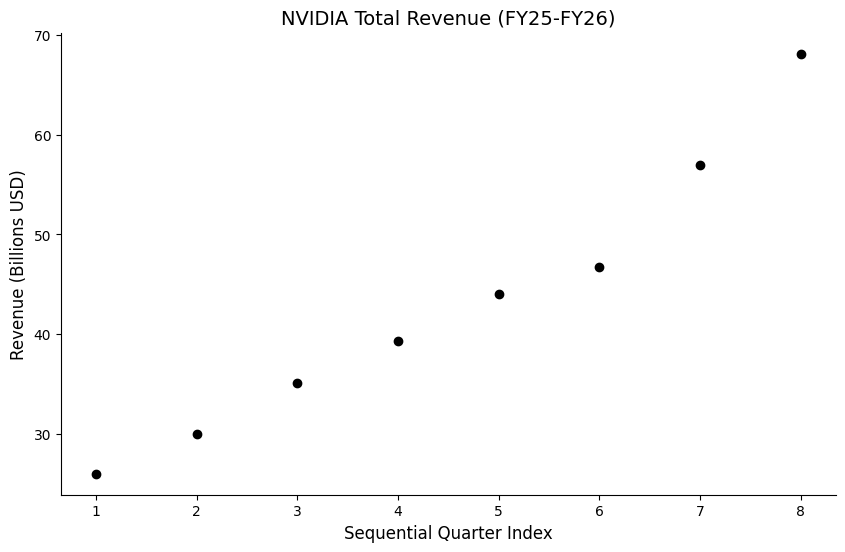

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

# Step 1: Ingestion of Modernized NVIDIA Dataset
# Data reflects the massive AI infrastructure capex boom of 2024-2026

data = {
    'Time_Index': np.array([1, 2, 3, 4, 5, 6, 7, 8]),
    'Total_Revenue_Billions': np.array([26.04, 30.04, 35.10, 39.33, 44.06, 46.74, 57.00, 68.10])
}
df = pd.DataFrame(data)

X = df[['Time_Index']]
y = df['Total_Revenue_Billions']

# Visual EDA (Adhering to Data-Ink Ratio principles)
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.title('NVIDIA Total Revenue (FY25-FY26)', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


Linear Training MSE (High Bias): 7.91


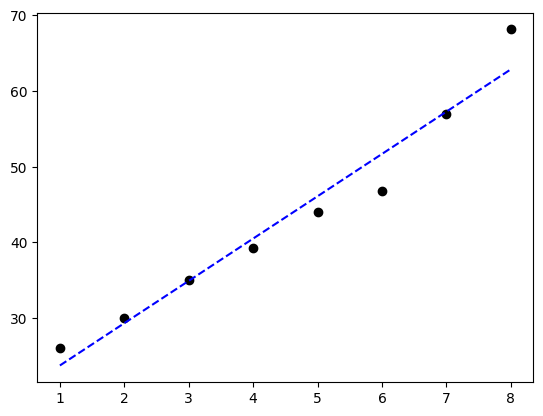

In [12]:
# Step 2: High Bias (Underfitting) Linear Model
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)
mse_linear = mean_squared_error(y, y_pred_linear)

print(f"Linear Training MSE (High Bias): {mse_linear:.2f}")

plt.scatter(X, y, color='black', label='Actual Revenue')

plt.plot(X, y_pred_linear, color='blue', linestyle='--', label='Linear Fit (High Bias)')


Polynomial Degree-7 Training MSE (High Variance): 0.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


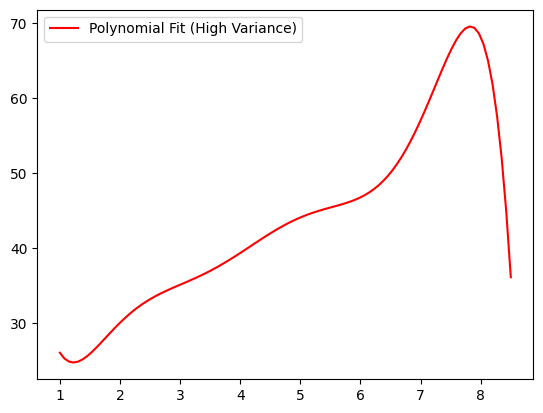

In [9]:
# Step 3: High Variance (Overfitting) Polynomial Model
poly_features = PolynomialFeatures(degree=7, include_bias=False)
X_poly = poly_features.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)
mse_poly = mean_squared_error(y, y_pred_poly)

print(f"Polynomial Degree-7 Training MSE (High Variance): {mse_poly:.2f}")

# Plotting the smooth polynomial curve
X_smooth = np.linspace(1, 8.5, 100).reshape(-1, 1)
X_smooth_poly = poly_features.transform(X_smooth)
y_smooth_poly = poly_reg.predict(X_smooth_poly)

plt.plot(X_smooth, y_smooth_poly, color='red', label='Polynomial Fit (High Variance)')
plt.legend()
plt.show()

In [10]:
# Step 4: The Extrapolation Collapse
X_future = np.array([[9]])  # Forecasting Q1 FY27
X_future_poly = poly_features.transform(X_future)
future_pred = poly_reg.predict(X_future_poly)

print(f"\nHallucinated Q1 FY27 Revenue Prediction: ${future_pred[0]:.2f} Billion")


Hallucinated Q1 FY27 Revenue Prediction: $-84.00 Billion


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
